# 1.3 Gaussian city

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# City-testing section (no real figures saved)

2025-10-08 10:40:30,396 - INFO - Initializing city
2025-10-08 10:40:30,397 - INFO - Calculating density profile for 1 core(s)
2025-10-08 10:40:30,401 - INFO - Running simulation for 5000 steps
2025-10-08 10:40:34,268 - INFO - Simulation completed in 3.87 seconds
2025-10-08 10:40:34,269 - INFO - In-simulation time passed: 7 days
2025-10-08 10:40:34,269 - INFO - Overall, statistics gathered over: 3 days
2025-10-08 10:40:34,272 - INFO - Cumulative rentals happened: 5749
2025-10-08 10:40:34,276 - INFO - Average rentals per car per day: 4.14
2025-10-08 10:40:34,279 - INFO - Average rental time per trip, min: 17.68
2025-10-08 10:40:34,283 - INFO - Average CM1 gain per trip, Eur: 4.42
2025-10-08 10:40:34,292 - INFO - Overall CM2 profit per day, Eur: -849.84
2025-10-08 10:40:34,296 - INFO - Average relocations per day: 0.00


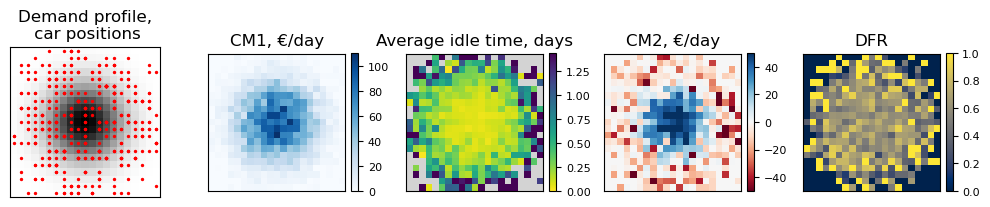

In [ ]:
# Testing grounds, not a real figure
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km
    "initial_r": 5, # km
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "density_sigma": 5, # Gaussian sigma. A bit smaller than default, to have close-to-zero demands
    "n_cars": 500,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "p_factor": 0.06,  # The simplest way to regulate trips/car/day and city profitability
    "tick_in_minutes": 2,
    "do_relocations": False,
}

import numpy as np
import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(5000)
plt.figure(figsize=(10, 5))
city.visualize()

# Introduction to Gaussian City

2025-10-08 10:40:35,079 - INFO - Initializing city
2025-10-08 10:40:35,081 - INFO - Calculating density profile for 1 core(s)


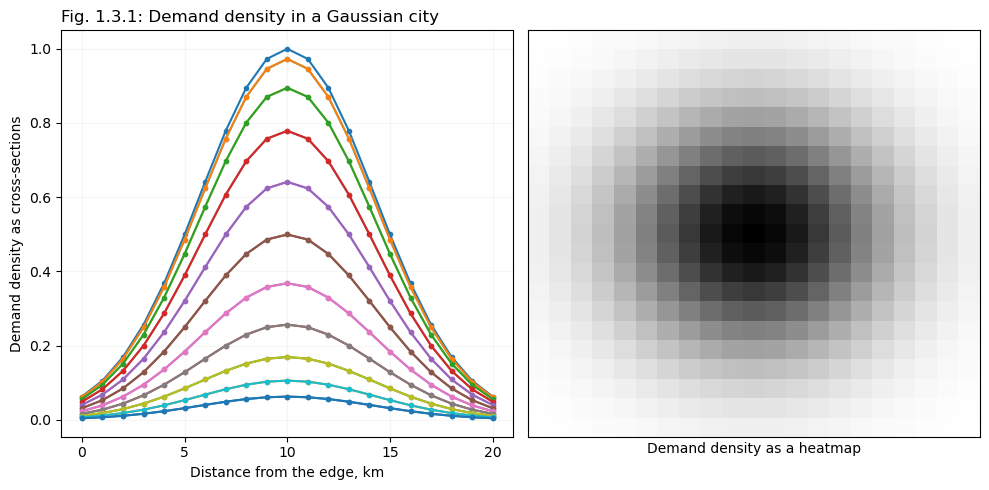

In [ ]:
# Population density
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km
    "grid_step": 1,
    "density_sigma": 6, # Gaussian sigma,
}

city = City(config)

# Visualize the city
plt.figure(figsize=(10, 5))

plt.subplot(121);
plt.plot(np.arange(city.grid_size)*config["grid_step"], city.demand, '.-');
plt.grid(alpha=0.1)
plt.xticks([0, 5, 10, 15, 20])
plt.xlabel('Distance from the edge, km')
plt.ylabel('Demand density as cross-sections')

plt.title("Fig. 1.3.1: Demand density in a Gaussian city", loc='left')

plt.subplot(122)
plt.imshow(city.demand.T, aspect='auto', interpolation='none',
          extent=[0, city.grid_size, 0, city.grid_size], cmap='gray_r', vmin=0, vmax=1);
plt.xlabel('Demand density as a heatmap')
plt.xticks([], [])
plt.yticks([], [])

plt.tight_layout()
plt.savefig("../figures/01simple_03city_01population.svg", dpi=300)

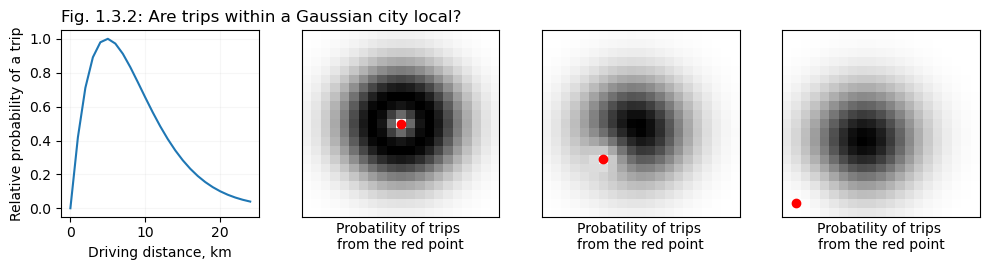

In [4]:
# Spatial mobility curve

n_grid = city.grid_size
density = city.demand

def trip_probability(distance):
    y = distance*np.exp(-(distance**1.2)/8) / 2.11
    return y

x = np.arange(0, 25)
curve = trip_probability(x)

def generate_local_map(i0, j0):
    local_trips = np.zeros(shape=(n_grid, n_grid))
    for i in range(n_grid):
        for j in range(n_grid):
            distance = np.sqrt((i-i0)**2 + (j-j0)**2)*config["grid_step"]
            local_trips[i, j] = trip_probability(distance)
    local_trips *= density
    local_trips /= local_trips.flatten().max()
    return local_trips

# Figure
plt.figure(figsize=(10, 2.8))
plt.subplot(141)
plt.plot(x, curve)
plt.grid(alpha=0.1)
plt.xlabel('Driving distance, km')
plt.ylabel('Relative probability of a trip')
plt.title("Fig. 1.3.2: Are trips within a Gaussian city local?", loc='left');

plt.subplot(142)
plt.imshow(generate_local_map(10, 10).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(10+0.5, 10+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.subplot(143)
plt.imshow(generate_local_map(6, 6).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(6+0.5, 6+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.subplot(144)
plt.imshow(generate_local_map(1, 1).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(1+0.5, 1+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.savefig("../figures/01simple_03city_02mobility.svg", dpi=300)

# Eventual distribution of cars

2025-10-08 10:40:36,134 - INFO - Initializing city
2025-10-08 10:40:36,135 - INFO - Calculating density profile for 1 core(s)
2025-10-08 10:40:36,181 - INFO - Running simulation for 20 steps
2025-10-08 10:40:36,212 - INFO - Simulation completed in 0.03 seconds
2025-10-08 10:40:36,214 - INFO - In-simulation time passed: 0 days
2025-10-08 10:40:36,215 - INFO - Overall, statistics gathered over: 0 days
2025-10-08 10:40:36,216 - INFO - Cumulative rentals happened: 62
2025-10-08 10:40:36,218 - INFO - Average rentals per car per day: 1.98
2025-10-08 10:40:36,224 - INFO - Average rental time per trip, min: 16.13
2025-10-08 10:40:36,227 - INFO - Average CM1 gain per trip, Eur: 4.03
2025-10-08 10:40:36,229 - INFO - Overall CM2 profit per day, Eur: -6040.96
2025-10-08 10:40:36,232 - INFO - Average relocations per day: 0.00
2025-10-08 10:40:36,266 - INFO - Running simulation for 3000 steps
2025-10-08 10:40:47,250 - INFO - Simulation completed in 10.98 seconds
2025-10-08 10:40:47,252 - INFO - In-s

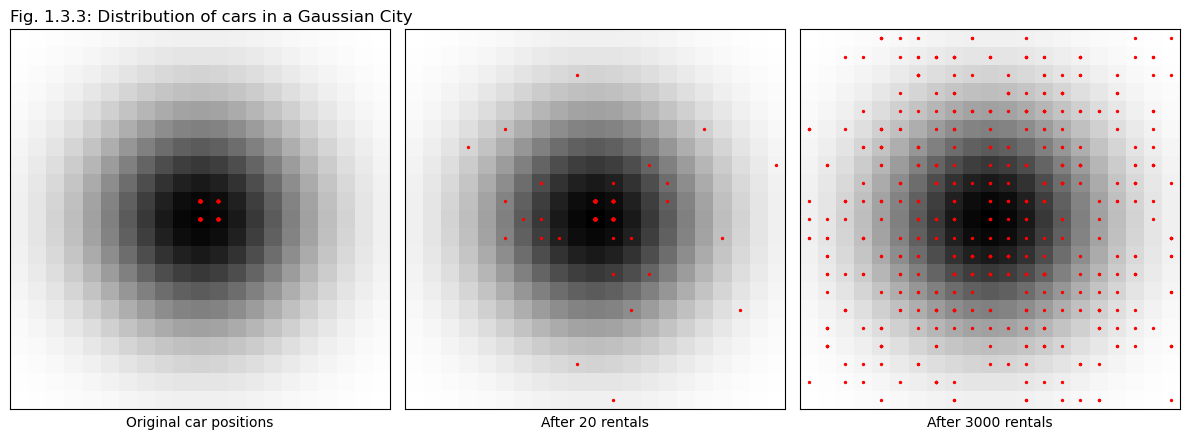

In [ ]:
# Evolution of car distribution
config = {
    "seed": 2,  # Random seed
    "city_width": 21, # km
    "grid_step": 1,
    "n_cars": 500,
    "initial_r": 1,
    "density_sigma": 6,
    "p_factor":0.5,
    "do_relocations": False,
}

import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
plt.figure(figsize=(12, 5))
plt.subplot(131)
city.visualize("cars")
plt.xlabel("Original car positions")
plt.title("Fig. 1.3.3: Distribution of cars in a Gaussian City", loc='left');
city.simulate(20)
plt.subplot(132)
city.visualize("cars")
plt.xlabel("After 20 rentals")
city.simulate(3000)
plt.subplot(133)
city.visualize("cars")
plt.xlabel("After 3000 rentals");
plt.savefig("../figures/01simple_03city_03cardistribution.svg", dpi=300)

# Typical stats - base state (no relocations, no price shenanigans, one core)

2025-10-08 10:40:48,666 - INFO - Initializing city
2025-10-08 10:40:48,672 - INFO - Calculating density profile for 1 core(s)
2025-10-08 10:40:48,687 - INFO - Running simulation for 30000 steps
2025-10-08 10:40:53,523 - INFO - ..Simulating step 5000 of 30000
2025-10-08 10:40:56,532 - INFO - ..Simulating step 10000 of 30000
2025-10-08 10:40:59,065 - INFO - ..Simulating step 15000 of 30000
2025-10-08 10:41:01,610 - INFO - ..Simulating step 20000 of 30000
2025-10-08 10:41:04,403 - INFO - ..Simulating step 25000 of 30000
2025-10-08 10:41:07,094 - INFO - Simulation completed in 18.40 seconds
2025-10-08 10:41:07,095 - INFO - In-simulation time passed: 42 days
2025-10-08 10:41:07,096 - INFO - Overall, statistics gathered over: 38 days
2025-10-08 10:41:07,097 - INFO - Cumulative rentals happened: 77179
2025-10-08 10:41:07,097 - INFO - Average rentals per car per day: 4.12
2025-10-08 10:41:07,098 - INFO - Average rental time per trip, min: 17.71
2025-10-08 10:41:07,099 - INFO - Average CM1 gain

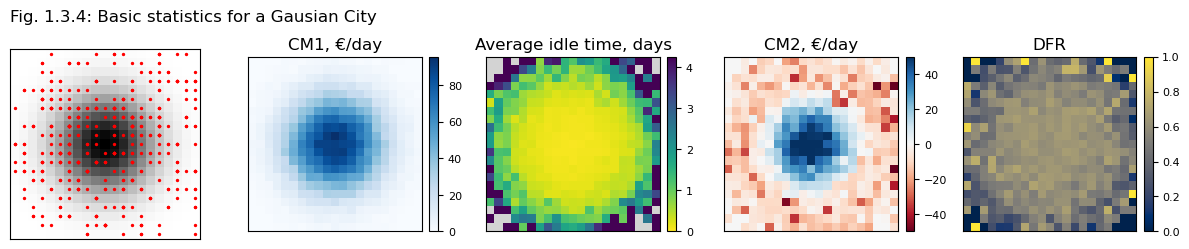

In [ ]:
# Nice Gaussian city
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km
    "initial_r": 5, # km
    "grid_step": 1, # km. Use 1 for ~intermediate resolution
    "density_sigma": 5, # Gaussian sigma. A bit smaller than default, to have close-to-zero demands
    "n_cars": 500,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "p_factor": 0.06,  # The simplest way to regulate trips/car/day and city profitability
    "tick_in_minutes": 2,
    "do_relocations": False,
}

import numpy as np
import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(30000)
plt.figure(figsize=(12, 3))
city.visualize()
f = plt.gcf()
ax = f.axes[0]
ax.set_title("")  # Clear the title
for text in ax.texts:
    text.remove()
ax.set_title("", pad=0)  # Clear the title
ax.set_title("Fig. 1.3.4: Basic statistics for a Gausian City", loc='left', pad=20)
plt.tight_layout();
plt.savefig("../figures/01simple_03city_04stats_maps.svg", dpi=300)

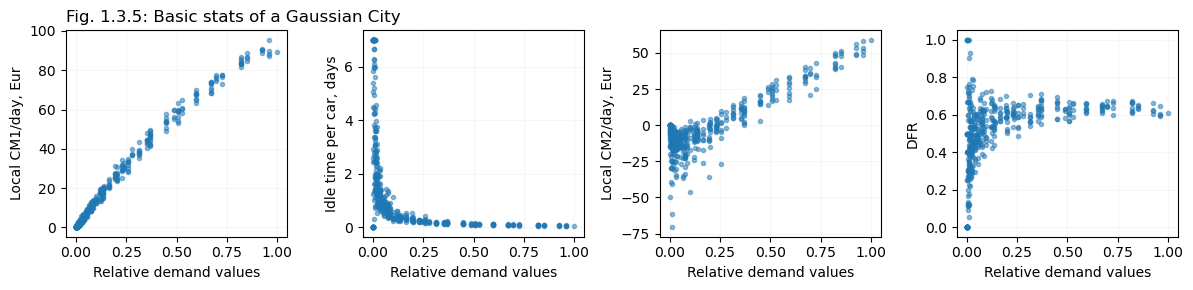

In [7]:
# Stats, use data from the previous run 👆

demand = city.demand.flatten()
cm1 = city.map_cm1.flatten() / city.n_days
cm2 = city.map_cm2.flatten() / city.n_days
idle_times = city.map_idle_time.flatten() * city.tick_in_minutes / 60 / 24 / np.maximum(1, city.map_n_rentals.flatten())
dfr = city.map_n_rentals.flatten() / np.maximum(1, city.map_n_appops.flatten())

plt.figure(figsize=(12, 3))
plt.subplot(141)
plt.title("Fig. 1.3.5: Basic stats of a Gaussian City", loc='left');
plt.plot(demand, cm1, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM1/day, Eur")

plt.subplot(142)
plt.plot(demand, np.minimum(7, idle_times), '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Idle time per car, days")

plt.subplot(143)
plt.plot(demand, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(144)
plt.plot(demand, dfr, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("DFR")

plt.tight_layout();
plt.savefig("../figures/01simple_03city_05stats_plots.svg", dpi=300)

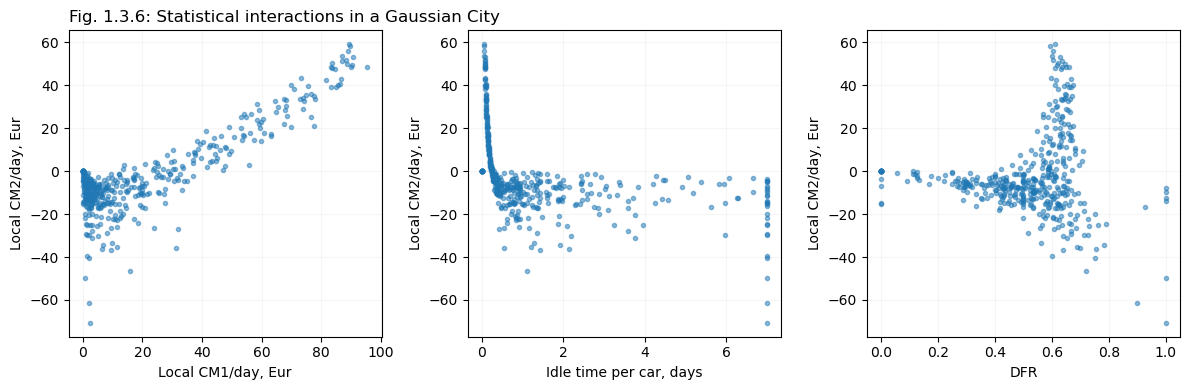

In [8]:
# Fancier stats (from the same run)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.title("Fig. 1.3.6: Statistical interactions in a Gaussian City", loc='left');
plt.plot(cm1, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.ylabel("Local CM2/day, Eur")
plt.xlabel("Local CM1/day, Eur")

plt.subplot(132)
plt.plot(np.minimum(idle_times, 7), cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Idle time per car, days")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(133)
plt.plot(dfr, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("DFR")
plt.ylabel("Local CM2/day, Eur")

plt.tight_layout();
plt.savefig("../figures/01simple_03city_06stats2_plots.svg", dpi=300)

# A flatter city

2025-10-08 10:45:28,573 - INFO - Initializing city
2025-10-08 10:45:28,581 - INFO - Calculating density profile for 1 core(s)


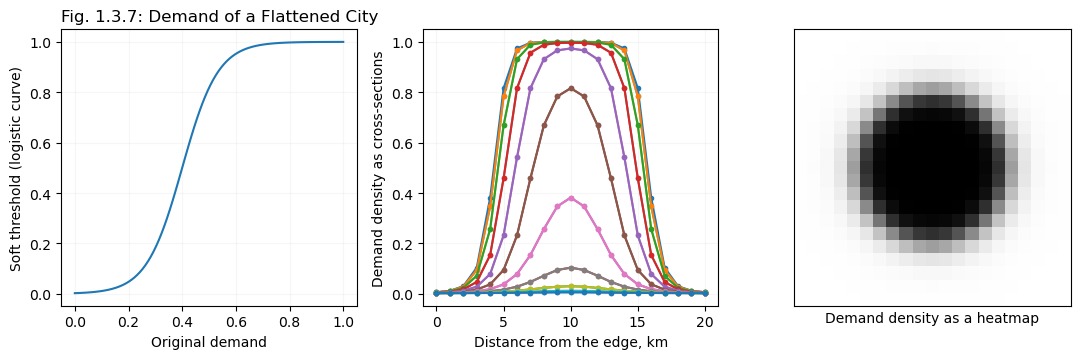

In [ ]:
# First check that we like the demand landscape
config = {
    "seed": 2,  # Random seed
    "city_width": 21, # km
    "grid_step": 1,
    "n_cars": 400,
    "initial_r": 3,
    "density_sigma": 6,
    "do_flatten_demand": True,  # Flatten the top
    "demand_flattening_threshold": 0.4,
    "demand_flattening_factor": 15,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "p_factor":0.5,
    "do_relocations": False,
}

import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)

flattener = lambda x: 1/(1+np.exp(
                city.demand_flattening_factor*(city.demand_flattening_threshold-x))
            )

# Visualize the city
plt.figure(figsize=(11, 3.7))
plt.subplot(131)
x = np.linspace(0, 1, 100)  # From 0 to 1
plt.plot(x, flattener(x), '-')
plt.grid(alpha=0.1)
plt.xlabel("Original demand")
plt.ylabel("Soft threshold (logistic curve)")
plt.title("Fig. 1.3.7: Demand of a Flattened City", loc='left')

plt.subplot(133)
plt.imshow(city.demand.T, aspect='auto', interpolation='none',
          extent=[0, city.grid_size, 0, city.grid_size], cmap='gray_r', vmin=0, vmax=1);
plt.xlabel('Demand density as a heatmap')
plt.gca().set_aspect('equal', adjustable='box')
plt.xticks([], [])
plt.yticks([], [])

plt.subplot(132);
plt.plot(np.arange(city.grid_size)*config["grid_step"], city.demand, '.-');
plt.grid(alpha=0.1)
plt.xticks([0, 5, 10, 15, 20])
plt.xlabel('Distance from the edge, km')
plt.ylabel('Demand density as cross-sections')

plt.tight_layout()
plt.savefig("../figures/01simple_03city_07flat_demand.svg", dpi=300)

2025-10-08 10:44:41,992 - INFO - Initializing city
2025-10-08 10:44:41,995 - INFO - Calculating density profile for 1 core(s)
2025-10-08 10:44:42,003 - INFO - Running simulation for 30000 steps
2025-10-08 10:44:46,432 - INFO - ..Simulating step 5000 of 30000
2025-10-08 10:44:52,337 - INFO - ..Simulating step 10000 of 30000
2025-10-08 10:44:56,980 - INFO - ..Simulating step 15000 of 30000
2025-10-08 10:45:01,894 - INFO - ..Simulating step 20000 of 30000
2025-10-08 10:45:06,397 - INFO - ..Simulating step 25000 of 30000
2025-10-08 10:45:09,583 - INFO - Simulation completed in 27.58 seconds
2025-10-08 10:45:09,584 - INFO - In-simulation time passed: 104 days
2025-10-08 10:45:09,585 - INFO - Overall, statistics gathered over: 94 days
2025-10-08 10:45:09,585 - INFO - Cumulative rentals happened: 134638
2025-10-08 10:45:09,588 - INFO - Average rentals per car per day: 3.59
2025-10-08 10:45:09,591 - INFO - Average rental time per trip, min: 19.56
2025-10-08 10:45:09,593 - INFO - Average CM1 ga

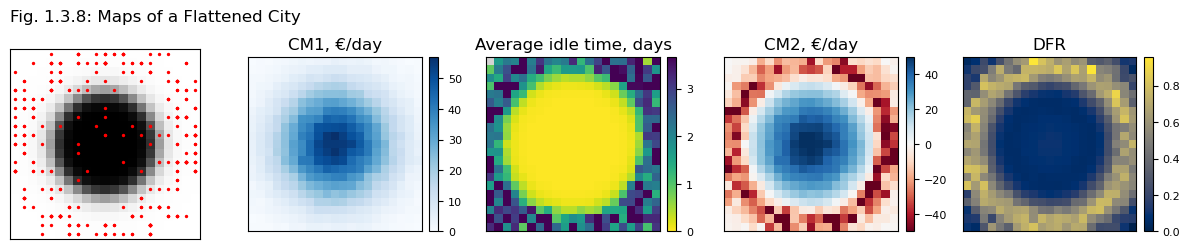

In [ ]:
# A flatter city
config = {
    "seed": 2,  # Random seed
    "city_width": 21, # km
    "grid_step": 1,
    "n_cars": 400,
    "initial_r": 3, # A bit wider, to facilitate distribution
    "density_sigma": 6,
    "settle_down_steps": 3000, # Number of steps without stats collection, for the system to settle down
    "p_factor":0.5,
    "do_relocations": False,
}

city = City(config)
threshold = 0.4
f = lambda x: 1/(1+np.exp(15*(threshold-x)))
city.demand = f(city.demand)

city.init_cars()
city.simulate(30000)
plt.figure(figsize=(12, 3))
city.visualize()
f = plt.gcf()
ax = f.axes[0]
ax.set_title("")  # Clear the title
for text in ax.texts:
    text.remove()
ax.set_title("", pad=0)  # Clear the title
ax.set_title("Fig. 1.3.8: Maps of a Flattened City", loc='left', pad=20)
plt.tight_layout();
plt.savefig("../figures/01simple_03city_08flat_maps.svg", dpi=300)

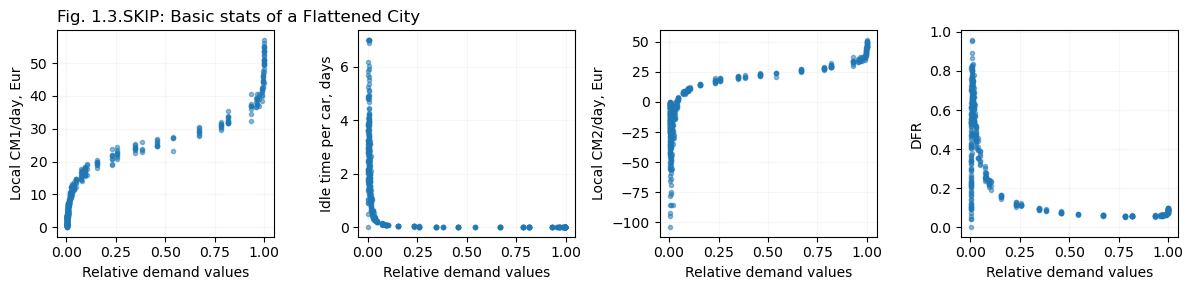

In [17]:
# Stats, use data from the previous run 👆

demand = city.demand.flatten()
cm1 = city.map_cm1.flatten() / city.n_days
cm2 = city.map_cm2.flatten() / city.n_days
idle_times = city.map_idle_time.flatten() * city.tick_in_minutes / 60 / 24 / np.maximum(1, city.map_n_rentals.flatten())
dfr = city.map_n_rentals.flatten() / np.maximum(1, city.map_n_appops.flatten())

plt.figure(figsize=(12, 3))
plt.subplot(141)
plt.title("Fig. 1.3.SKIP: Basic stats of a Flattened City", loc='left');
plt.plot(demand, cm1, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM1/day, Eur")

plt.subplot(142)
plt.plot(demand, np.minimum(7, idle_times), '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Idle time per car, days")

plt.subplot(143)
plt.plot(demand, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(144)
plt.plot(demand, dfr, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Relative demand values")
plt.ylabel("DFR")

plt.tight_layout()

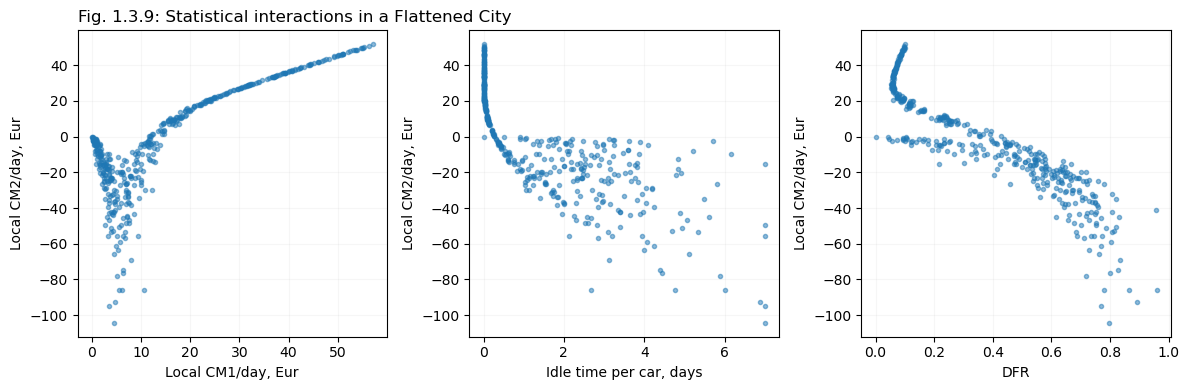

In [18]:
# Fancier stats (from the same run)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.title("Fig. 1.3.9: Statistical interactions in a Flattened City", loc='left');
plt.plot(cm1, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.ylabel("Local CM2/day, Eur")
plt.xlabel("Local CM1/day, Eur")

plt.subplot(132)
plt.plot(np.minimum(idle_times, 7), cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("Idle time per car, days")
plt.ylabel("Local CM2/day, Eur")

plt.subplot(133)
plt.plot(dfr, cm2, '.', alpha=0.5)
plt.grid(alpha=0.1)
plt.xlabel("DFR")
plt.ylabel("Local CM2/day, Eur")

plt.tight_layout();
plt.savefig("../figures/01simple_03city_09flat_stats.svg", dpi=300)